In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord
from matplotlib.lines import Line2D

In [11]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'stix'

In [12]:
fname = "DR19seisages_samp_train456789_net10_method14151617_cluster1819_LTt23k_WRC.fits"
data = fits.getdata(fname, extname="STARFLOW_TABLE", memmap=True)

with fits.open(fname, memmap=True) as hdul:
    cols = hdul["STARFLOW_TABLE"].columns.names
    print(len(cols))
    print(cols)

452
['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id', 'catalogid', 'catalogid21', 'catalogid25', 'catalogid31', 'n_associated', 'n_neighborhood', 'sdss5_target_flags', 'sdss4_apogee_target1_flags', 'sdss4_apogee_target2_flags', 'sdss4_apogee2_target1_flags', 'sdss4_apogee2_target2_flags', 'sdss4_apogee2_target3_flags', 'sdss4_apogee_member_flags', 'sdss4_apogee_extra_target_flags', 'ra', 'dec', 'l', 'b', 'plx', 'e_plx', 'pmra', 'e_pmra', 'pmde', 'e_pmde', 'gaia_v_rad', 'gaia_e_v_rad', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag', 'ph_qual', 'bl_flg', 'cc_flg', 'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac', 'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac', 'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags', 'mag4_5', 'd4_5m', 'rms_f4_5', 'sqf_4_5', 'mf4_5', 'csf', 'zgr_teff', 'zgr_e_teff', 'zgr_logg', 'zgr_e_logg', 'zgr_fe_h', 'zgr_e_fe_h', 'zgr_e', 'zgr_e_e', 'zg

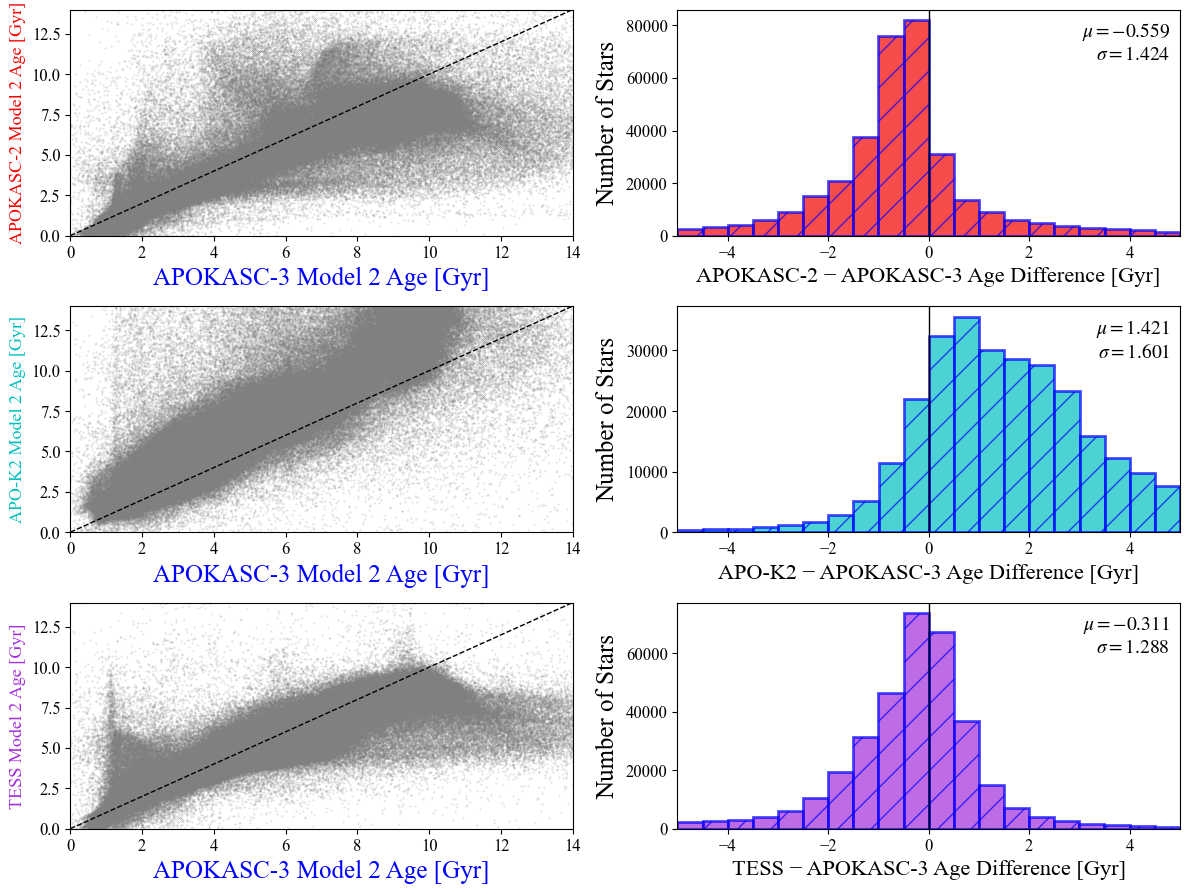

In [13]:
# FIGURE 5

comparisons = [
    ('LT_AP2_Net2_Age', 'APOKASC-2', '#f50000'),
    ('LT_AK2_Net2_Age', 'APO-K2', 'c'),
    ('LT_TESS_Net2_Age', 'TESS', '#a32cdc')
]

ap3_col = 'LT_AP3_Net2_Age'
ap3_label = 'APOKASC-3'
ap3_color = 'b'

nrows = len(comparisons)
fig, axs = plt.subplots(nrows, 2, figsize=(12, 3*nrows))

for i, (other_col, other_label, other_color) in enumerate(comparisons):

    feh_col = "fe_h"
    c_col   = "c_h"
    n_col   = "n_h"

    teff_col = 'teff'
    logg_col = 'logg'
    mh_col   = 'm_h_atm'
    flag_bad_col = 'flag_bad'

    good = np.where(
        np.isfinite(data[ap3_col]) & np.isfinite(data[other_col]) &
        (data[ap3_col] > 0) &
        (data[other_col] > 0) &

        (True if feh_col is None else (np.isfinite(data[feh_col]) & (data[feh_col] != -9999))) &
        (True if c_col  is None else (np.isfinite(data[c_col])   & (data[c_col]   != -9999))) &
        (True if n_col  is None else (np.isfinite(data[n_col])   & (data[n_col]   != -9999))) &

        (data[teff_col] > 3700) & (data[teff_col] < 5300) &
        (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
        (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
        (data[flag_bad_col] == False)
    )[0]

    age_ap3   = np.asarray(data[ap3_col], dtype=float)[good]
    age_other = np.asarray(data[other_col], dtype=float)[good]

    diff = age_other - age_ap3
    keep = np.abs(diff) <= 5

    age_ap3_filt   = age_ap3[keep]
    age_other_filt = age_other[keep]
    diff_filt      = diff[keep]

    mu = np.mean(diff_filt)
    sigma = np.std(diff_filt)

    axs[i, 0].scatter(age_ap3, age_other, s=0.1, alpha=0.4, c='grey')
    axs[i, 0].plot([0, 14], [0, 14], 'k--', lw=1)
    axs[i, 0].set_xlim(0, 14)
    axs[i, 0].set_ylim(0, 14)
    axs[i, 0].set_xlabel(f'{ap3_label} Model 2 Age [Gyr]', color=ap3_color, fontsize=18)
    axs[i, 0].set_ylabel(f'{other_label} Model 2 Age [Gyr]', color=other_color, fontsize=13)

    axs[i, 1].hist(
        diff_filt, bins=20, alpha=0.7, linewidth=2,
        facecolor=other_color, hatch='/', edgecolor=ap3_color, fill=True
    )
    axs[i, 1].axvline(0, color='k', lw=1)
    axs[i, 1].set_xlim(-5, 5)
    axs[i, 1].set_ylabel('Number of Stars', fontsize=18)
    axs[i, 1].set_xlabel(f'{other_label} − APOKASC-3 Age Difference [Gyr]', fontsize=16)
    axs[i, 1].text(
        0.98, 0.95,
        rf'$\mu={mu:.3f}$' + '\n' + rf'$\sigma={sigma:.3f}$',
        transform=axs[i, 1].transAxes,
        ha='right', va='top',
        fontsize=14
    )

plt.tight_layout(rect=[0, 0, 1, 1.005])
plt.show()

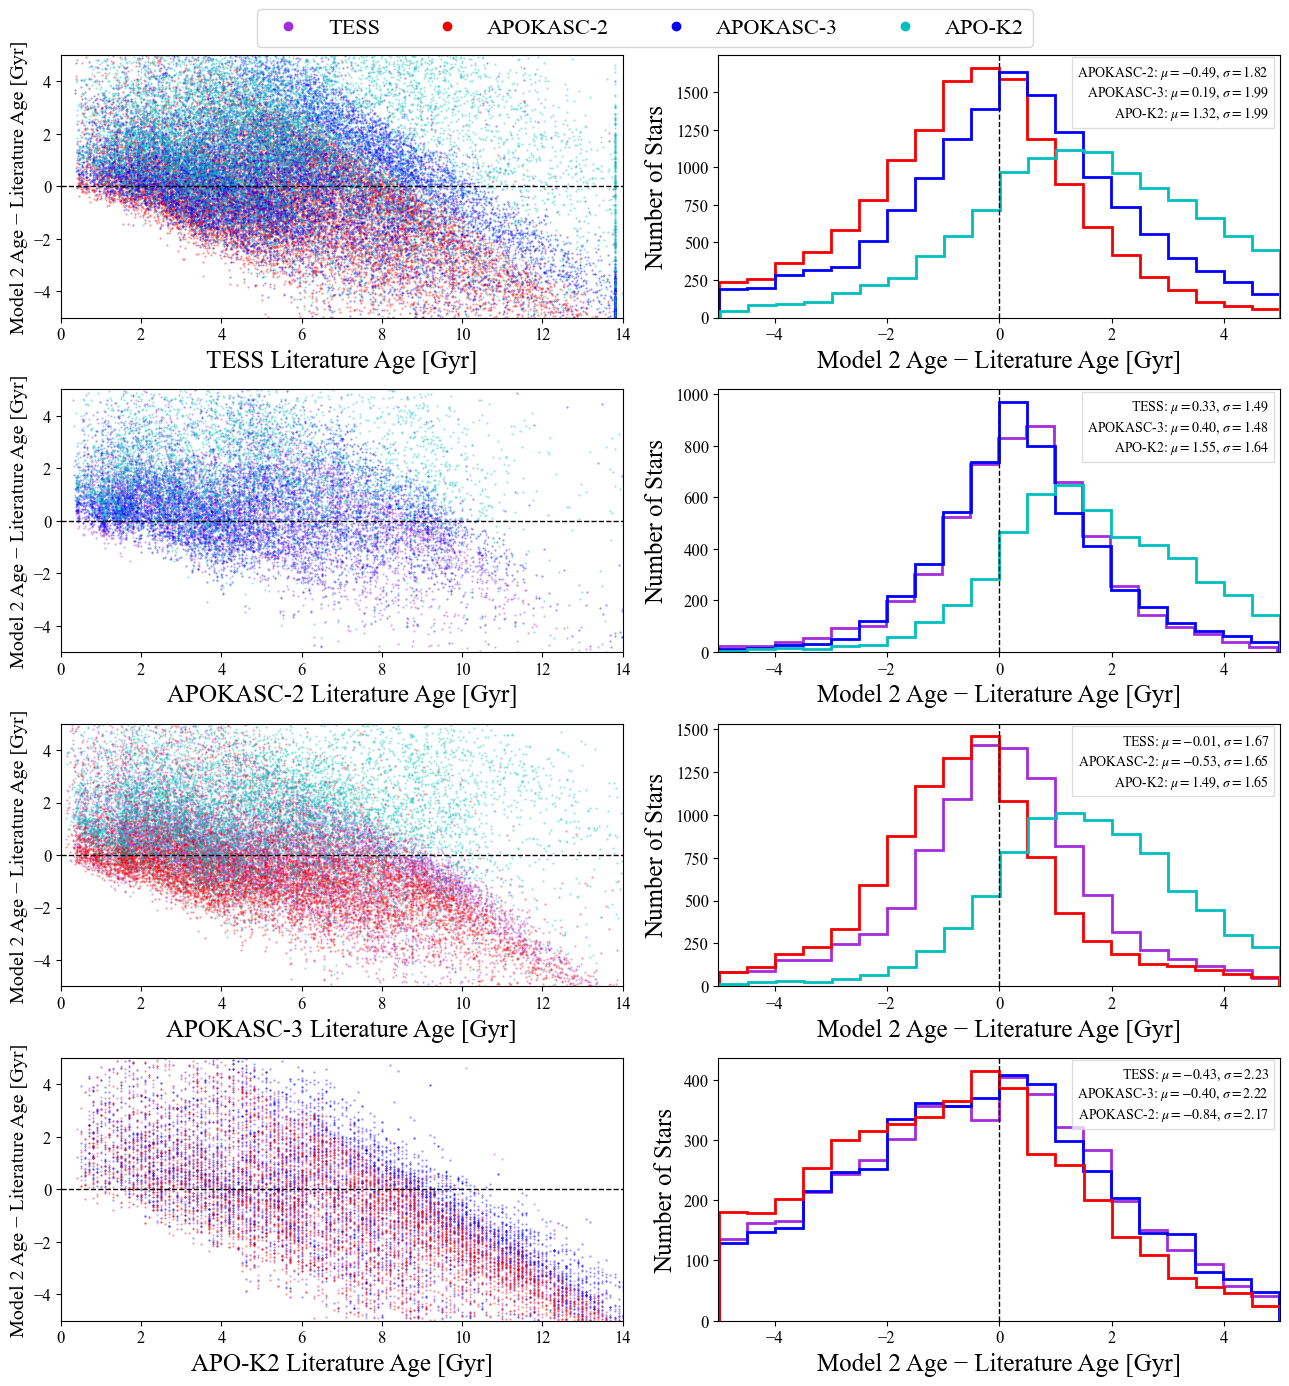

In [14]:
# FIGURE 9

model_colors = {
    "TESS": "#a32cdc",
    "APOKASC-2": "#f50000",
    "APOKASC-3": "b",
    "APO-K2": "c"
}

rows = [
    {
        "lit_col": "TESS_Age_T25",
        "lit_label": "TESS Literature",
        "models": [
            ("LT_AP2_Net2_Age", "APOKASC-2"),
            ("LT_AP3_Net2_Age", "APOKASC-3"),
            ("LT_AK2_Net2_Age", "APO-K2")
        ]
    },
    {
        "lit_col": "APOKASC2_Age_P18",
        "lit_label": "APOKASC-2 Literature",
        "models": [
            ("LT_TESS_Net2_Age", "TESS"),
            ("LT_AP3_Net2_Age", "APOKASC-3"),
            ("LT_AK2_Net2_Age", "APO-K2")
        ]
    },
    {
        "lit_col": "APOKASC3_Age_P25",
        "lit_label": "APOKASC-3 Literature",
        "models": [
            ("LT_TESS_Net2_Age", "TESS"),
            ("LT_AP2_Net2_Age", "APOKASC-2"),
            ("LT_AK2_Net2_Age", "APO-K2")
        ]
    },
    {
        "lit_col": "APOK2_Age_W24_incRC",
        "lit_label": "APO-K2 Literature",
        "models": [
            ("LT_TESS_Net2_Age", "TESS"),
            ("LT_AP3_Net2_Age", "APOKASC-3"),
            ("LT_AP2_Net2_Age", "APOKASC-2")
        ]
    }
]

feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

teff_col = "teff"
logg_col = "logg"
mh_col   = "m_h_atm"
flag_bad_col = "flag_bad"

fig, axs = plt.subplots(4, 2, figsize=(13, 14))

for i, row in enumerate(rows):

    lit_col = row["lit_col"]
    lit_label = row["lit_label"]

    ax_scatter = axs[i, 0]
    ax_hist = axs[i, 1]

    stats_lines = []

    for model_col, model_label in row["models"]:

        color = model_colors[model_label]

        good = np.where(
            np.isfinite(data[lit_col]) & np.isfinite(data[model_col]) &
            (data[lit_col] > 0) &
            (data[model_col] > 0) &

            np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
            np.isfinite(data[c_col])   & (data[c_col]   != -9999) &
            np.isfinite(data[n_col])   & (data[n_col]   != -9999) &

            (data[teff_col] > 3700) & (data[teff_col] < 5300) &
            (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
            (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
            (data[flag_bad_col] == False)
        )[0]

        lit_age = np.asarray(data[lit_col], dtype=float)[good]
        model_age = np.asarray(data[model_col], dtype=float)[good]

        diff = model_age - lit_age

        keep = np.abs(diff) <= 5

        lit_age_filt = lit_age[keep]
        diff_filt = diff[keep]

        mu = np.mean(diff_filt)
        sigma = np.std(diff_filt)

        stats_lines.append(rf"{model_label}: $\mu={mu:.2f}$, $\sigma={sigma:.2f}$")

        ax_scatter.scatter(
            lit_age_filt,
            diff_filt,
            s=0.2,
            alpha=0.5,
            color=color
        )

        ax_hist.hist(
            diff_filt,
            bins=20,
            histtype="step",
            linewidth=2,
            color=color
        )

    ax_scatter.axhline(0, color="k", linestyle="--", linewidth=1)
    ax_scatter.set_xlim(0, 14)
    ax_scatter.set_ylim(-5, 5)
    ax_scatter.set_xlabel(f"{lit_label} Age [Gyr]", fontsize=18)
    ax_scatter.set_ylabel("Model 2 Age − Literature Age [Gyr]", fontsize=14.5)

    ax_hist.axvline(0, color="k", linestyle="--", linewidth=1)
    ax_hist.set_xlim(-5, 5)
    ax_hist.set_xlabel("Model 2 Age − Literature Age [Gyr]", fontsize=18)
    ax_hist.set_ylabel("Number of Stars", fontsize=18)

    stats_text = "\n".join(stats_lines)
    ax_hist.text(
        0.98, 0.97,
        stats_text,
        transform=ax_hist.transAxes,
        ha='right', va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='lightgray')
    )

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', color=model_colors["TESS"],
           markersize=6, label="TESS"),
    Line2D([0], [0], marker='o', linestyle='None', color=model_colors["APOKASC-2"],
           markersize=6, label="APOKASC-2"),
    Line2D([0], [0], marker='o', linestyle='None', color=model_colors["APOKASC-3"],
           markersize=6, label="APOKASC-3"),
    Line2D([0], [0], marker='o', linestyle='None', color=model_colors["APO-K2"],
           markersize=6, label="APO-K2")
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.995),
    ncol=5,
    frameon=True,
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

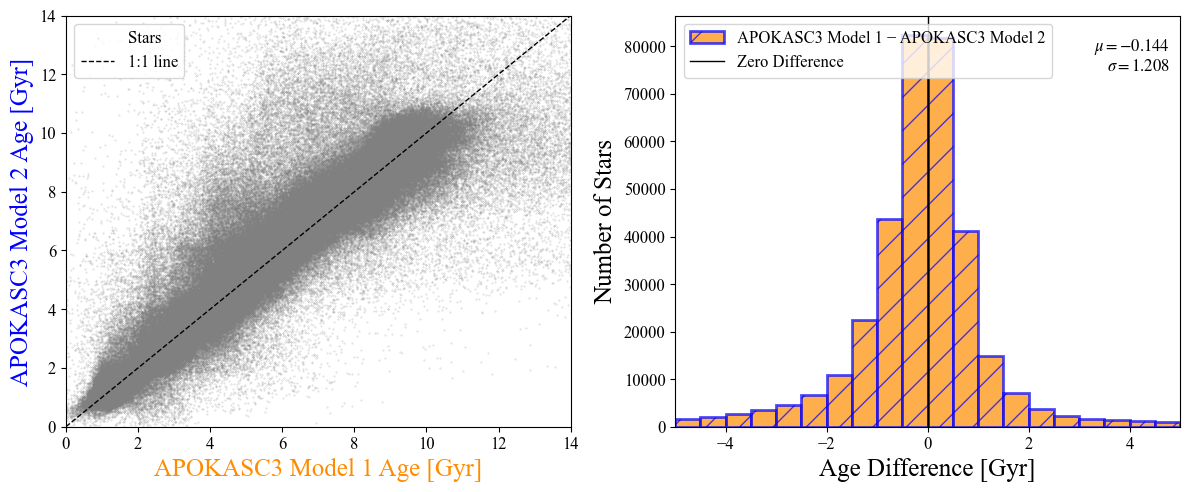

In [15]:
# TOP TWO PANELS - FIGURE 4

comparisons = [
    ('LT_AP3_Net1_Age', 'LT_AP3_Net2_Age',
     'APOKASC3 Model 1', 'APOKASC3 Model 2', 'APOKASC3 Model 1 vs 2', 'darkorange', 'b')
]

nrows = len(comparisons)
fig, axs = plt.subplots(nrows, 2, figsize=(12, 5*nrows))

if nrows == 1:
    axs = np.array([axs])

for i, (c1, c2, l1, l2, title, color1, color2) in enumerate(comparisons):

    agecolumn = c1
    baseage   = c2

    feh_col = "fe_h"
    c_col   = "c_h"
    n_col   = "n_h"

    teff_col = 'teff'
    logg_col = 'logg'
    mh_col   = 'm_h_atm'
    flag_bad_col = 'flag_bad'

    good = np.where(
        np.isfinite(data[agecolumn]) & np.isfinite(data[baseage]) &
        (data[agecolumn] > 0) &
        (data[baseage]   > 0) &

        (True if feh_col is None else (np.isfinite(data[feh_col]) & (data[feh_col] != -9999))) &
        (True if c_col  is None else (np.isfinite(data[c_col])   & (data[c_col]   != -9999))) &
        (True if n_col  is None else (np.isfinite(data[n_col])   & (data[n_col]   != -9999))) &

        (data[teff_col] > 3700) & (data[teff_col] < 5300) &
        (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
        (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
        (data[flag_bad_col] == False)
    )[0]

    age1 = np.asarray(data[c1], dtype=float)[good]
    age2 = np.asarray(data[c2], dtype=float)[good]
    diff = age1 - age2
    keep = np.abs(diff) <= 5
    
    age1_filt = age1[keep]
    age2_filt = age2[keep]
    diff_filt = diff[keep]

    mu = np.mean(diff_filt)
    sigma = np.std(diff_filt)

    axs[i, 0].scatter(age1, age2, s=0.1, alpha=0.4, c='grey', label='Stars')
    axs[i, 0].plot([0, 14], [0, 14], 'k--', lw=1, label='1:1 line')
    axs[i, 0].set_xlim(0, 14)
    axs[i, 0].set_ylim(0, 14)
    axs[i, 0].set_ylabel(f'{l2} Age [Gyr]', color=color2)
    axs[i, 0].set_xlabel(f'{l1} Age [Gyr]', color=color1)
    axs[i, 0].legend(loc='upper left')

    axs[i, 1].hist(
        diff_filt, bins=20, alpha=0.7, hatch='/', linewidth=2,
        facecolor=color1, edgecolor=color2, fill=True,
        label=f'{l1} − {l2}'
    )
    axs[i, 1].axvline(0, color='k', lw=1, label='Zero Difference')
    axs[i, 1].set_xlim(-5, 5)
    axs[i, 1].set_ylabel('Number of Stars')
    axs[i, 1].set_xlabel('Age Difference [Gyr]')
    axs[i, 1].text(
        0.98, 0.95,
        rf'$\mu={mu:.3f}$' + '\n' + rf'$\sigma={sigma:.3f}$',
        transform=axs[i, 1].transAxes,
        ha='right', va='top',
        fontsize=12
    )
    axs[i, 1].legend(loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 1.005])
plt.savefig('Figure4.png', dpi=600)
plt.show()

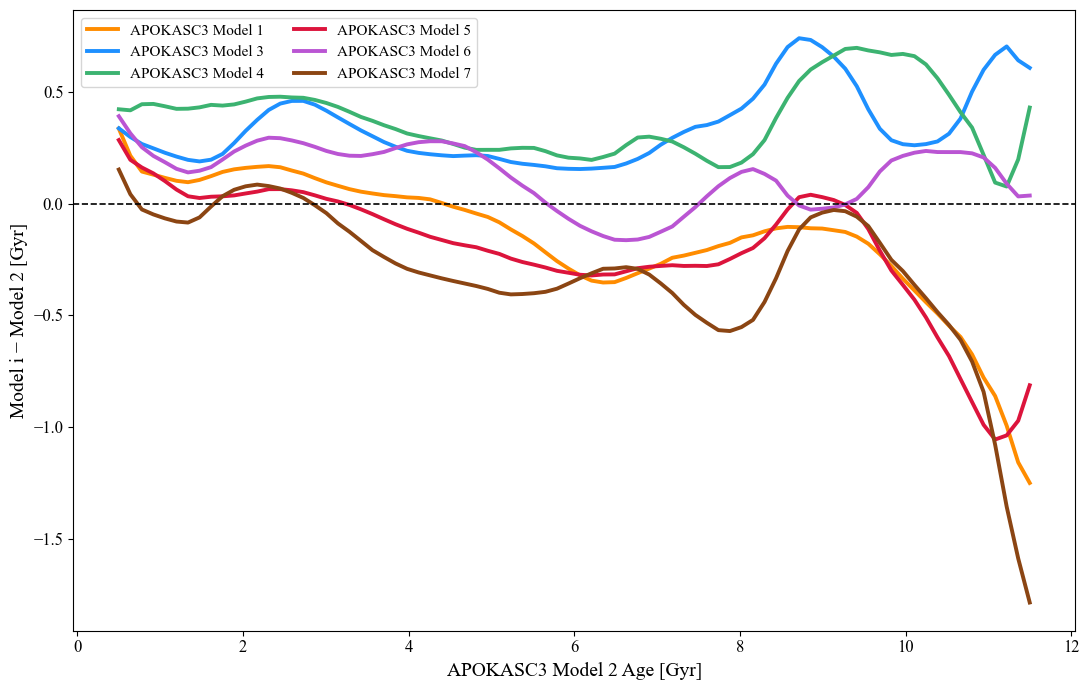

In [16]:
# BOTTOM LEFT PANEL - FIGURE 4

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

base_col = 'LT_AP3_Net2_Age'
base_label = 'APOKASC3 Model 2'

comparisons = [
    ('LT_AP3_Net1_Age', 'APOKASC3 Model 1', 'darkorange'),
    ('LT_AP3_Net3_Age', 'APOKASC3 Model 3', 'dodgerblue'),
    ('LT_AP3_Net4_Age', 'APOKASC3 Model 4', 'mediumseagreen'),
    ('LT_AP3_Net5_Age', 'APOKASC3 Model 5', 'crimson'),
    ('LT_AP3_Net6_Age', 'APOKASC3 Model 6', 'mediumorchid'),
    ('LT_AP3_Net7_Age', 'APOKASC3 Model 7', 'saddlebrown')
]

feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

teff_col = 'teff'
logg_col = 'logg'
mh_col   = 'm_h_atm'
flag_bad_col = 'flag_bad'

base_good = (
    (np.isfinite(data[feh_col]) & (data[feh_col] != -9999)) &
    (np.isfinite(data[c_col])   & (data[c_col]   != -9999)) &
    (np.isfinite(data[n_col])   & (data[n_col]   != -9999)) &
    (data[teff_col] > 3700) & (data[teff_col] < 5300) &
    (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
    (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
    (data[flag_bad_col] == False)
)

fig, ax = plt.subplots(figsize=(11, 7))

x_centers = np.linspace(0.5, 11.5, 80)

half_width = 0.5

for comp_col, comp_label, color in comparisons:
    good = np.where(
        base_good &
        np.isfinite(data[base_col]) &
        np.isfinite(data[comp_col]) &
        (data[base_col] > 0) &
        (data[comp_col] > 0)
    )[0]

    x = np.asarray(data[base_col], dtype=float)[good]
    y = np.asarray(data[comp_col], dtype=float)[good]
    diff = y - x

    medians = []
    valid_x = []

    for xc in x_centers:
        m = (x >= xc - half_width) & (x <= xc + half_width)

        if np.sum(m) >= 300:
            medians.append(np.median(diff[m]))
            valid_x.append(xc)

    medians = np.array(medians)
    valid_x = np.array(valid_x)

    ax.plot(valid_x, medians, color=color, lw=2.8, label=comp_label)

ax.axhline(0, color='k', linestyle='--', lw=1.2)

ax.set_xlabel(f'{base_label} Age [Gyr]', fontsize=14)
ax.set_ylabel('Model i − Model 2 [Gyr]', fontsize=14)

ax.legend(loc='upper left', fontsize=11, ncol=2)

plt.tight_layout()
plt.show()

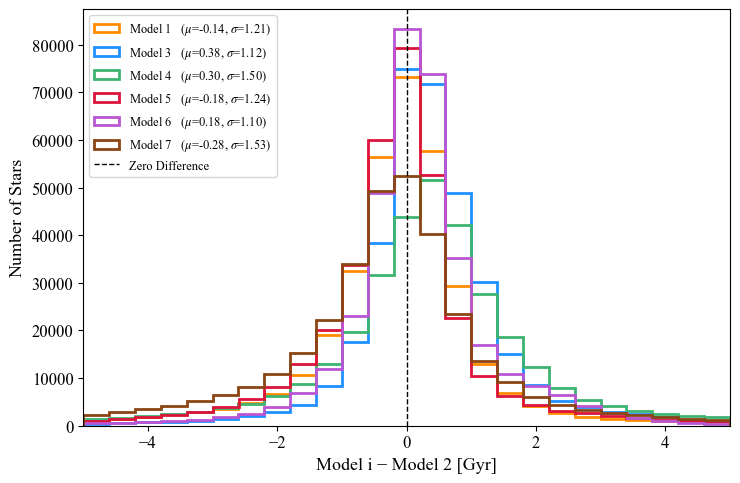

In [17]:
# BOTTOM RIGHT PANEL - FIGURE 4

base_col = 'LT_AP3_Net2_Age'

comparisons = [
    ('LT_AP3_Net1_Age', 'Model 1', 'darkorange'),
    ('LT_AP3_Net3_Age', 'Model 3', 'dodgerblue'),
    ('LT_AP3_Net4_Age', 'Model 4', 'mediumseagreen'),
    ('LT_AP3_Net5_Age', 'Model 5', 'crimson'),
    ('LT_AP3_Net6_Age', 'Model 6', 'mediumorchid'),
    ('LT_AP3_Net7_Age', 'Model 7', 'saddlebrown')
]

feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

teff_col = 'teff'
logg_col = 'logg'
mh_col   = 'm_h_atm'
flag_bad_col = 'flag_bad'

base_good = (
    (np.isfinite(data[feh_col]) & (data[feh_col] != -9999)) &
    (np.isfinite(data[c_col])   & (data[c_col]   != -9999)) &
    (np.isfinite(data[n_col])   & (data[n_col]   != -9999)) &
    (data[teff_col] > 3700) & (data[teff_col] < 5300) &
    (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
    (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
    (data[flag_bad_col] == False)
)

fig, ax = plt.subplots(figsize=(7.5, 5.2))

for col, label, color in comparisons:

    good = np.where(
        base_good &
        np.isfinite(data[base_col]) & np.isfinite(data[col]) &
        (data[base_col] > 0) & (data[col] > 0)
    )[0]

    age2 = np.asarray(data[base_col], dtype=float)[good]
    agei = np.asarray(data[col], dtype=float)[good]

    diff = agei - age2
    diff_filt = diff[np.abs(diff) <= 5]

    mu = np.mean(diff_filt)
    sigma = np.std(diff_filt)

    ax.hist(
        diff_filt,
        bins=25,
        histtype='step',
        linewidth=2,
        color=color,
        label=f'{label}   ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})'
    )

ax.axvline(0, color='k', linestyle='--', lw=1, label='Zero Difference')
ax.set_xlim(-5, 5)
ax.set_xlabel('Model i − Model 2 [Gyr]', fontsize=13)
ax.set_ylabel('Number of Stars', fontsize=13)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

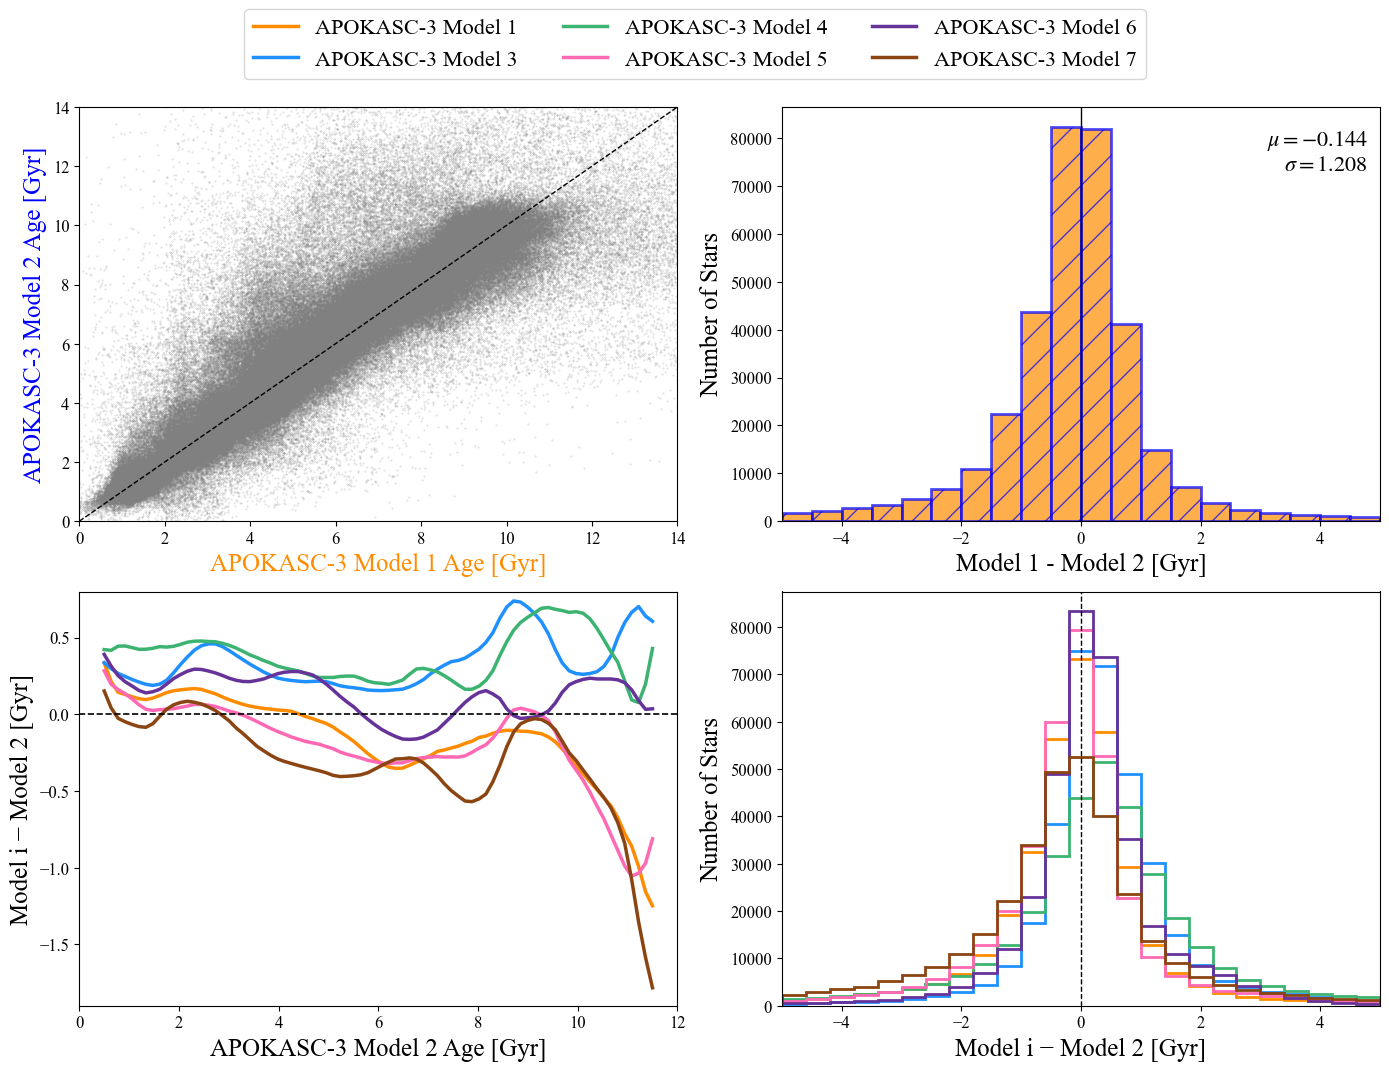

In [18]:
# FIGURE 4

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

base_col = 'LT_AP3_Net2_Age'
base_label = 'APOKASC-3 Model 2'

single_col   = 'LT_AP3_Net1_Age'
single_label = 'APOKASC-3 Model 1'
single_color = 'darkorange'
base_color   = 'b'

comparisons = [
    ('LT_AP3_Net1_Age', 'APOKASC-3 Model 1', 'darkorange'),
    ('LT_AP3_Net3_Age', 'APOKASC-3 Model 3', 'dodgerblue'),
    ('LT_AP3_Net4_Age', 'APOKASC-3 Model 4', 'mediumseagreen'),
    ('LT_AP3_Net5_Age', 'APOKASC-3 Model 5', 'hotpink'),
    ('LT_AP3_Net6_Age', 'APOKASC-3 Model 6', 'rebeccapurple'),
    ('LT_AP3_Net7_Age', 'APOKASC-3 Model 7', 'saddlebrown')
]

feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

teff_col = 'teff'
logg_col = 'logg'
mh_col   = 'm_h_atm'
flag_bad_col = 'flag_bad'

base_good = (
    (np.isfinite(data[feh_col]) & (data[feh_col] != -9999)) &
    (np.isfinite(data[c_col])   & (data[c_col]   != -9999)) &
    (np.isfinite(data[n_col])   & (data[n_col]   != -9999)) &
    (data[teff_col] > 3700) & (data[teff_col] < 5300) &
    (data[logg_col] > 0.9)  & (data[logg_col] < 3.3) &
    (data[mh_col]   > -2.0) & (data[mh_col]   < 0.6) &
    (data[flag_bad_col] == False)
)

fig, axs = plt.subplots(2, 2, figsize=(14, 11))
ax_scatter = axs[0, 0]
ax_hist1   = axs[0, 1]
ax_runmed  = axs[1, 0]
ax_histall = axs[1, 1]

good_single = np.where(
    base_good &
    np.isfinite(data[base_col]) &
    np.isfinite(data[single_col]) &
    (data[base_col] > 0) &
    (data[single_col] > 0)
)[0]

age2_single = np.asarray(data[base_col], dtype=float)[good_single]
age1_single = np.asarray(data[single_col], dtype=float)[good_single]

diff_single = age1_single - age2_single
diff_single_filt = diff_single[np.abs(diff_single) <= 5]

mu_single = np.mean(diff_single_filt)
sigma_single = np.std(diff_single_filt)

ax_scatter.scatter(age1_single, age2_single, s=0.1, alpha=0.4, c='grey')
ax_scatter.plot([0, 14], [0, 14], 'k--', lw=1)
ax_scatter.set_xlim(0, 14)
ax_scatter.set_ylim(0, 14)
ax_scatter.set_xlabel(f'{single_label} Age [Gyr]', color=single_color)
ax_scatter.set_ylabel(f'{base_label} Age [Gyr]', color=base_color)

ax_hist1.hist(
    diff_single_filt,
    bins=20,
    alpha=0.7,
    hatch='/',
    linewidth=2,
    facecolor=single_color,
    edgecolor=base_color,
    fill=True
)
ax_hist1.axvline(0, color='k', lw=1)
ax_hist1.set_xlim(-5, 5)
ax_hist1.set_xlabel('Model 1 - Model 2 [Gyr]')
ax_hist1.set_ylabel('Number of Stars')
ax_hist1.text(
    0.98, 0.95,
    rf'$\mu={mu_single:.3f}$' + '\n' + rf'$\sigma={sigma_single:.3f}$',
    transform=ax_hist1.transAxes,
    ha='right', va='top', fontsize=16
)

x_centers = np.linspace(0.5, 11.5, 80)
half_width = 0.5

for comp_col, comp_label, color in comparisons:
    good = np.where(
        base_good &
        np.isfinite(data[base_col]) &
        np.isfinite(data[comp_col]) &
        (data[base_col] > 0) &
        (data[comp_col] > 0)
    )[0]

    x = np.asarray(data[base_col], dtype=float)[good]
    y = np.asarray(data[comp_col], dtype=float)[good]
    diff = y - x

    medians = []
    valid_x = []

    for xc in x_centers:
        m = (x >= xc - half_width) & (x <= xc + half_width)
        if np.sum(m) >= 300:
            medians.append(np.median(diff[m]))
            valid_x.append(xc)

    medians = np.array(medians)
    valid_x = np.array(valid_x)

    ax_runmed.plot(valid_x, medians, color=color, lw=2.5, label=comp_label)

ax_runmed.axhline(0, color='k', linestyle='--', lw=1.2)
ax_runmed.set_xlim(0, 12)
ax_runmed.set_ylim(-1.9, 0.8)
ax_runmed.set_xlabel(f'{base_label} Age [Gyr]')
ax_runmed.set_ylabel('Model i − Model 2 [Gyr]')

for comp_col, comp_label, color in comparisons:
    good = np.where(
        base_good &
        np.isfinite(data[base_col]) &
        np.isfinite(data[comp_col]) &
        (data[base_col] > 0) &
        (data[comp_col] > 0)
    )[0]

    x = np.asarray(data[base_col], dtype=float)[good]
    y = np.asarray(data[comp_col], dtype=float)[good]
    diff = y - x
    diff_filt = diff[np.abs(diff) <= 5]

    mu = np.mean(diff_filt)
    sigma = np.std(diff_filt)

    ax_histall.hist(
        diff_filt,
        bins=25,
        histtype='step',
        linewidth=2,
        color=color,
        label=f'{comp_label}  ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})'
    )

ax_histall.axvline(0, color='k', linestyle='--', lw=1, label='Zero Difference')
ax_histall.set_xlim(-5, 5)
ax_histall.set_xlabel('Model i − Model 2 [Gyr]')
ax_histall.set_ylabel('Number of Stars')

legend_handles = [
    Line2D([0], [0], color=color, lw=2.5, label=comp_label)
    for _, comp_label, color in comparisons
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()